In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

project_root = current_dir.parents[2] 

if str(project_root) not in sys.path:
    
    sys.path.append(str(project_root))

print(f"Project root added: {project_root}")

Project root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [2]:
import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from tqdm import tqdm
import os
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU, BatchNorm1d, Embedding
from torch_geometric.nn import GINEConv, global_mean_pool

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch_geometric.datasets import AQSOL

data_dir = os.path.join(project_root, "data", "AQSOL")

train_set = AQSOL(root=data_dir, split='train')

val_set = AQSOL(root=data_dir, split='val')

test_set = AQSOL(root=data_dir, split='test')

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

dataset = AQSOL(root=data_dir)

num_atom_types = int(dataset.data.x.max()) + 1

num_bond_types = int(dataset.data.edge_attr.max()) + 1

print(f"Total Atom Types: {num_atom_types}")

print(f"Total Bond Types: {num_bond_types}")

def get_stats(split_name):

    dataset = AQSOL(root = data_dir , split = split_name)

    num_graphs = len(dataset)

    num_nodes = sum([d.num_nodes for d in dataset])/num_graphs

    num_edges = sum([d.num_edges for d in dataset])/num_graphs

    print(f'{split_name} set statistics:')
    print(f'Number of graphs: {num_graphs}')
    print(f'Average number of nodes per graph: {num_nodes}')
    print(f'Average number of edges per graph: {num_edges}')

    return dataset
train_stats = get_stats("train")
val_stats = get_stats("val")
test_stats = get_stats("test")

/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_8584/2878740469.py:19: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  num_atom_types = int(dataset.data.x.max()) + 1
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_8584/2878740469.py:21: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  num_bond_types = int(dataset.data.edge_attr.max()) + 1


Total Atom Types: 65
Total Bond Types: 5
train set statistics:
Number of graphs: 7836
Average number of nodes per graph: 15.420239918325676
Average number of edges per graph: 30.66309341500766
val set statistics:
Number of graphs: 998
Average number of nodes per graph: 23.48997995991984
Average number of edges per graph: 50.75551102204409
test set statistics:
Number of graphs: 999
Average number of nodes per graph: 28.663663663663662
Average number of edges per graph: 61.131131131131134


In [4]:
# Find number of atom types (node features)
# .x usually has shape [num_nodes, 1] for AQSOL
num_atom_types = int(dataset.data.x.max()) + 1

# Find number of bond types (edge features)
# .edge_attr usually has shape [num_edges, 1]
num_bond_types = int(dataset.data.edge_attr.max()) + 1

print(f"Total Atom Types: {num_atom_types}")
print(f"Total Bond Types: {num_bond_types}")

Total Atom Types: 65
Total Bond Types: 5


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_8584/644734513.py:3: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  num_atom_types = int(dataset.data.x.max()) + 1
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_8584/644734513.py:7: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  num_bond_types = int(dataset.data.edge_attr.max()) + 1


In [5]:
class SimpleGINE(torch.nn.Module):
    def __init__(self, hidden_dim=256):
        super(SimpleGINE, self).__init__()
        
        # 1. Input Embeddings (Atom types and Bond types)
        self.node_emb = Embedding(65, hidden_dim)
        self.edge_emb = Embedding(5, hidden_dim)

        # 2. GINE Layer 1
        self.mlp1 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(self.mlp1)
        self.bn1 = BatchNorm1d(hidden_dim)

        # 3. GINE Layer 2
        self.mlp2 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(self.mlp2)
        self.bn2 = BatchNorm1d(hidden_dim)

        # 4. GINE Layer 3
        self.mlp3 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv3 = GINEConv(self.mlp3)
        self.bn3 = BatchNorm1d(hidden_dim)

        # 4. GINE Layer 4
        self.mlp4 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv4 = GINEConv(self.mlp4)
        self.bn4 = BatchNorm1d(hidden_dim)

        # 5. Final Readout
        self.post_mp = Sequential(
            Linear(hidden_dim, hidden_dim // 2), 
            ReLU(), 
            Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        # Convert raw integer features to embeddings
        x = self.node_emb(x.squeeze(-1))
        edge_attr = self.edge_emb(edge_attr)

        # Layer 1
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)

        # Layer 2
        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        # Layer 3
        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)

        # Layer 4
        x = self.conv4(x, edge_index, edge_attr)
        x = self.bn4(x)
        x = F.relu(x)

        # Global Pooling (Graph-level representation)
        x = global_mean_pool(x, batch)

        # Regression Output
        return self.post_mp(x).view(-1)

Epoch 001 | Train MAE: 1.3376 | Val MAE: 4.6401
Epoch 002 | Train MAE: 1.0783 | Val MAE: 1.2213
Epoch 003 | Train MAE: 1.0308 | Val MAE: 1.2618
Epoch 004 | Train MAE: 1.0012 | Val MAE: 1.3604
Epoch 005 | Train MAE: 0.9584 | Val MAE: 1.3091
Epoch 006 | Train MAE: 0.9502 | Val MAE: 1.3162
Epoch 007 | Train MAE: 0.9574 | Val MAE: 1.4745
Epoch 008 | Train MAE: 0.9090 | Val MAE: 1.2189
Epoch 009 | Train MAE: 0.8905 | Val MAE: 1.2907
Epoch 010 | Train MAE: 0.8678 | Val MAE: 1.0760
Epoch 011 | Train MAE: 0.8535 | Val MAE: 1.1890
Epoch 012 | Train MAE: 0.8565 | Val MAE: 1.7862
Epoch 013 | Train MAE: 0.8329 | Val MAE: 1.5795
Epoch 014 | Train MAE: 0.8051 | Val MAE: 1.7217
Epoch 015 | Train MAE: 0.8226 | Val MAE: 2.3078
Epoch 016 | Train MAE: 0.8088 | Val MAE: 1.1032
Epoch 017 | Train MAE: 0.8017 | Val MAE: 1.7492
Epoch 018 | Train MAE: 0.7973 | Val MAE: 1.2140
Epoch 019 | Train MAE: 0.7631 | Val MAE: 1.2344
Epoch 020 | Train MAE: 0.7728 | Val MAE: 1.1304
Epoch 021 | Train MAE: 0.7783 | Val MAE:

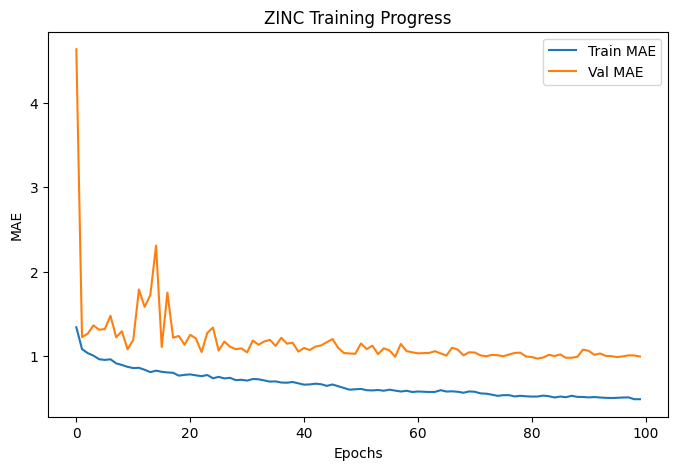


Final Test MAE: 1.2579


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleGINE(hidden_dim=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15 , min_lr=1e-6)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128)
test_loader = DataLoader(test_set, batch_size=128)

def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = F.l1_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_set)

@torch.no_grad()
def test(loader):
    model.eval()
    total_mae = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        total_mae += F.l1_loss(out, data.y).item() * data.num_graphs
    return total_mae / len(loader.dataset)

train_maes, val_maes = [], []
for epoch in range(1, 101):
    t_mae = train()
    v_mae = test(val_loader)
    train_maes.append(t_mae)
    val_maes.append(v_mae)
    scheduler.step(v_mae)
    #if epoch % 10 == 0:
    print(f"Epoch {epoch:03d} | Train MAE: {t_mae:.4f} | Val MAE: {v_mae:.4f}")

# Final Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_maes, label='Train MAE')
plt.plot(val_maes, label='Val MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('ZINC Training Progress')
plt.legend()
plt.show()

# Final Inference
final_test_mae = test(test_loader)
print(f"\nFinal Test MAE: {final_test_mae:.4f}")

In [7]:
import math
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d, Embedding
from torch_geometric.nn import GINEConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import AQSOL
from pathlib import Path
from copy import deepcopy
import matplotlib.pyplot as plt

# --- Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr_init = 1e-3
lr_factor = 0.5
min_lr = 1e-6
num_epochs = 200            # Max epochs
batch_size = 128
early_stop_patience = 20    # Stop if validation doesn't improve for 20 epochs
min_delta = 0.0001          # Minimum improvement required

# ICML Style Reporting: Run multiple seeds
seeds = [0, 1, 2, 3, 4]

# --- Dataset Loading (AQSOL) ---
data_path = Path.cwd() / 'data'
print(f"Loading AQSOL dataset to {data_path}...")

# AQSOL is a regression dataset (solubility prediction)
train_set = AQSOL(root=str(data_path), split='train')
val_set = AQSOL(root=str(data_path), split='val')
test_set = AQSOL(root=str(data_path), split='test')

print(f"Train samples: {len(train_set)}")
print(f"Val samples:   {len(val_set)}")
print(f"Test samples:  {len(test_set)}")

# --- Model Definition (SimpleGINE) ---
class SimpleGINE(torch.nn.Module):
    def __init__(self, hidden_dim=256):
        super(SimpleGINE, self).__init__()
        
        # 1. Input Embeddings 
        # AQSOL node features are atom types (integers), edge features are bond types (integers)
        # Using 65 for atom types and 5 for bond types covers standard organic molecules
        self.node_emb = Embedding(65, hidden_dim)
        self.edge_emb = Embedding(5, hidden_dim)

        # 2. GINE Layer 1
        self.mlp1 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(self.mlp1)
        self.bn1 = BatchNorm1d(hidden_dim)

        # 3. GINE Layer 2
        self.mlp2 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(self.mlp2)
        self.bn2 = BatchNorm1d(hidden_dim)

        # 4. GINE Layer 3
        self.mlp3 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv3 = GINEConv(self.mlp3)
        self.bn3 = BatchNorm1d(hidden_dim)

        # 5. GINE Layer 4
        self.mlp4 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv4 = GINEConv(self.mlp4)
        self.bn4 = BatchNorm1d(hidden_dim)

        # 6. Final Readout
        self.post_mp = Sequential(
            Linear(hidden_dim, hidden_dim // 2), 
            ReLU(), 
            Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        # x shape: [num_nodes, 1] -> squeeze to [num_nodes] for Embedding
        x = self.node_emb(x.squeeze(-1))
        edge_attr = self.edge_emb(edge_attr)

        # Layer 1
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)

        # Layer 2
        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        # Layer 3
        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)

        # Layer 4
        x = self.conv4(x, edge_index, edge_attr)
        x = self.bn4(x)
        x = F.relu(x)

        # Global Pooling (Graph-level representation)
        x = global_mean_pool(x, batch)

        # Regression Output
        return self.post_mp(x).view(-1)

# --- Helper Functions ---
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def run_epoch(model, loader, optimizer=None, is_train=False):
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    total_graphs = 0
    
    context = torch.enable_grad() if is_train else torch.no_grad()
    
    with context:
        for data in loader:
            data = data.to(device)
            
            if is_train:
                optimizer.zero_grad()
            
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            loss = F.l1_loss(out, data.y)
            
            if is_train:
                loss.backward()
                optimizer.step()

            # Weighted sum of loss (L1 Loss is MAE)
            total_loss += loss.item() * data.num_graphs
            total_graphs += data.num_graphs

    return total_loss / total_graphs

# --- Main Experiment Loop ---
results_test_mae = []

print(f"\nStarting experiment with {len(seeds)} seeds: {seeds}")

for seed in seeds:
    print(f"\n--- Run Seed: {seed} ---")
    set_seed(seed)
    
    # 1. Initialize Loaders
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # 2. Initialize Model & Optimizer
    model = SimpleGINE(hidden_dim=256).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_init)
    
    # 3. LR Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=lr_factor, patience=15, min_lr=min_lr
    )

    # 4. Training Loop with Early Stopping
    best_val_mae = math.inf
    best_state = None
    epochs_no_improve = 0
    
    # Lists to track curve for this seed (optional, for debugging)
    train_curve, val_curve = [], []

    for epoch in range(1, num_epochs + 1):
        train_mae = run_epoch(model, train_loader, optimizer, is_train=True)
        val_mae = run_epoch(model, val_loader, is_train=False)
        
        train_curve.append(train_mae)
        val_curve.append(val_mae)

        # Step scheduler based on Validation MAE
        scheduler.step(val_mae)
        
        # Check Early Stopping / Best Model
        if val_mae < (best_val_mae - min_delta):
            best_val_mae = val_mae
            best_state = deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {epoch} | Best Val MAE: {best_val_mae:.4f}")
            break
            
        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Ep {epoch:03d} | Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | LR: {current_lr:.2e}")

    # 5. Test Inference
    if best_state is not None:
        model.load_state_dict(best_state)
    
    test_mae = run_epoch(model, test_loader, is_train=False)
    print(f"Seed {seed} Result -> Test MAE: {test_mae:.4f}")
    results_test_mae.append(test_mae)

# --- Final ICML Style Reporting ---
mae_mean = np.mean(results_test_mae)
mae_std = np.std(results_test_mae)

print("\n" + "="*45)
print("FINAL AQSOL RESULTS (ICML Style)")
print("="*45)
print(f"Test MAE: {mae_mean:.4f} ± {mae_std:.4f}")
print("="*45)

Loading AQSOL dataset to /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/zinc_aqsol_bcos_regression/data...


Extracting /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/zinc_aqsol_bcos_regression/data/aqsol_graph_raw.zip
Processing...
Done!


Train samples: 7836
Val samples:   998
Test samples:  999

Starting experiment with 5 seeds: [0, 1, 2, 3, 4]

--- Run Seed: 0 ---


KeyboardInterrupt: 

## BCos GINE (edge-aware) on AQSOL
This section defines a BCos version of GINE (uses `edge_attr`) so the comparison with the vanilla `GINEConv` model above is faithful.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import MeanAggregation


class Readout(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int | None = None, out_channels: int = 1, *, b: float = 2, max_out: int = 1):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            self.readout = nn.Sequential(
                BcosLinear(in_channels, hidden_channels, b=b, max_out=max_out),
                nn.ReLU(),
                BcosLinear(hidden_channels, out_channels, b=b, max_out=max_out),
            )

    def forward(self, x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError


class ReadoutThenAgg(Readout):
    def __init__(self, in_channels: int, hidden_channels: int | None = None, out_channels: int = 1, *, b: float = 2, max_out: int = 1):
        super().__init__(in_channels, hidden_channels, out_channels, b=b, max_out=max_out)
        # Use mean aggregation to match `global_mean_pool` used in the vanilla GINE baseline.
        self.agg = MeanAggregation()

    def forward(self, x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        z = self.readout(x)
        out = self.agg(z, batch)
        return out


class BcosGINEConv(MessagePassing):
    def __init__(
        self,
        hidden_dim: int,
        *,
        b: float = 2,
        max_out: int = 1,
        eps: float = 0.0,
        train_eps: bool = False,
    ):
        super().__init__(aggr="add")
        self.nn = nn.Sequential(
            BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out),
            nn.ReLU(),
            BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out),
        )
        if train_eps:
            self.eps = nn.Parameter(torch.tensor([eps], dtype=torch.float))
        else:
            self.register_buffer("eps", torch.tensor([eps], dtype=torch.float))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        out = (1 + self.eps) * x + out
        return self.nn(out)

    def message(self, x_j: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        # GINE-style message: ReLU(x_j + e_ij)
        return F.relu(x_j + edge_attr)

In [22]:
class BCosGINE(nn.Module):
    def __init__(self, hidden_dim: int = 256, *, b: float = 2, max_out: int = 1):
        super().__init__()
        # Match the vanilla baseline: same vocab sizes and embedding dim.
        self.node_emb = nn.Embedding(65, hidden_dim)
        self.edge_emb = nn.Embedding(5, hidden_dim)

        # Match the vanilla baseline: 3 GINE-style conv blocks + BN + ReLU.
        self.conv1 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.conv2 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.conv3 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        #self.conv4 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        #self.bn4 = nn.BatchNorm1d(hidden_dim)

        # Use ReadoutThenAgg as requested (mean aggregation to align with `global_mean_pool`).
        self.readout = ReadoutThenAgg(hidden_dim, hidden_dim // 2, out_channels=1, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.node_emb(x.squeeze(-1).long())
        edge_attr = edge_attr.view(-1).long()
        edge_attr = self.edge_emb(edge_attr)

        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)

        #x = self.conv4(x, edge_index, edge_attr)
        #x = self.bn4(x)
        #x = F.relu(x)

        out = self.readout(x, batch)
        return out.view(-1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BCosGINE(nn.Module):
    def __init__(self, hidden_dim: int = 256, dropout: float = 0.5, *, b: float = 2, max_out: int = 1):
        super().__init__()
        self.dropout_rate = dropout
        
        # Match the vanilla baseline: same vocab sizes and embedding dim.
        self.node_emb = nn.Embedding(65, hidden_dim)
        self.edge_emb = nn.Embedding(5, hidden_dim)

        # Match the vanilla baseline: 3 GINE-style conv blocks + BN + ReLU.
        self.conv1 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        
        self.conv2 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        
        self.conv3 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        
        #self.conv4 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        #self.bn4 = nn.BatchNorm1d(hidden_dim)

        # Use ReadoutThenAgg as requested (mean aggregation to align with `global_mean_pool`).
        self.readout = ReadoutThenAgg(hidden_dim, hidden_dim // 2, out_channels=1, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.node_emb(x.squeeze(-1).long())
        edge_attr = edge_attr.view(-1).long()
        edge_attr = self.edge_emb(edge_attr)

        # Block 1
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)

        # Block 2
        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)

        # Block 3
        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)

        # Block 4
        x = self.conv4(x, edge_index, edge_attr)
        x = self.bn4(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)

        out = self.readout(x, batch)
        return out.view(-1)

In [16]:
from copy import deepcopy


def _bcos_train_one_epoch(model: nn.Module, loader, optimizer: torch.optim.Optimizer, device: torch.device) -> float:
    model.train()
    total_mae = 0.0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = F.l1_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_mae += loss.detach().item() * data.num_graphs
    return total_mae / len(loader.dataset)


@torch.no_grad()
def _bcos_eval_mae(model: nn.Module, loader, device: torch.device) -> float:
    model.eval()
    total_mae = 0.0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        total_mae += F.l1_loss(out, data.y).item() * data.num_graphs
    return total_mae / len(loader.dataset)

[BCosGINE] Epoch 001 | Train MAE: 1.5812 | Val MAE: 1.8094
[BCosGINE] Epoch 002 | Train MAE: 1.2897 | Val MAE: 1.3267
[BCosGINE] Epoch 003 | Train MAE: 1.2693 | Val MAE: 1.3214
[BCosGINE] Epoch 004 | Train MAE: 1.2219 | Val MAE: 1.4513
[BCosGINE] Epoch 005 | Train MAE: 1.2238 | Val MAE: 1.9149
[BCosGINE] Epoch 006 | Train MAE: 1.1746 | Val MAE: 2.9948
[BCosGINE] Epoch 007 | Train MAE: 1.1924 | Val MAE: 1.4314
[BCosGINE] Epoch 008 | Train MAE: 1.1378 | Val MAE: 1.3043
[BCosGINE] Epoch 009 | Train MAE: 1.1224 | Val MAE: 1.5196
[BCosGINE] Epoch 010 | Train MAE: 1.1079 | Val MAE: 1.2732
[BCosGINE] Epoch 011 | Train MAE: 1.0905 | Val MAE: 1.3216
[BCosGINE] Epoch 012 | Train MAE: 1.0806 | Val MAE: 1.3343
[BCosGINE] Epoch 013 | Train MAE: 1.0960 | Val MAE: 1.6138
[BCosGINE] Epoch 014 | Train MAE: 1.0548 | Val MAE: 1.7830
[BCosGINE] Epoch 015 | Train MAE: 1.0783 | Val MAE: 1.2447
[BCosGINE] Epoch 016 | Train MAE: 1.0787 | Val MAE: 1.2745
[BCosGINE] Epoch 017 | Train MAE: 1.0655 | Val MAE: 1.24

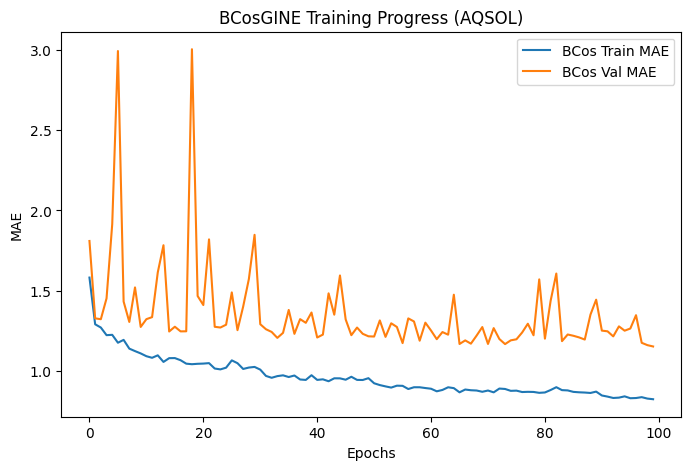

In [23]:
# Match the vanilla baseline hyperparams as closely as possible.
bcos_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bcos_model = BCosGINE(hidden_dim=150, b=0.5, max_out=1).to(bcos_device)

bcos_optimizer = torch.optim.Adam(bcos_model.parameters(), lr=0.001)
bcos_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    bcos_optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-6
 )

num_epochs = 100  # set to 100 to match the vanilla run above
bcos_train_maes, bcos_val_maes = [], []
best_val = float('inf')
best_state = None

for epoch in range(1, num_epochs + 1):
    train_mae = _bcos_train_one_epoch(bcos_model, train_loader, bcos_optimizer, bcos_device)
    val_mae = _bcos_eval_mae(bcos_model, val_loader, bcos_device)
    bcos_train_maes.append(train_mae)
    bcos_val_maes.append(val_mae)
    bcos_scheduler.step(val_mae)

    if val_mae < best_val:
        best_val = val_mae
        best_state = deepcopy(bcos_model.state_dict())

    print(f"[BCosGINE] Epoch {epoch:03d} | Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f}")

if best_state is not None:
    bcos_model.load_state_dict(best_state)

bcos_test_mae = _bcos_eval_mae(bcos_model, test_loader, bcos_device)
print(f"\n[BCosGINE] Best Val MAE: {best_val:.4f}")
print(f"[BCosGINE] Final Test MAE: {bcos_test_mae:.4f}")

# Plot curves (same style as vanilla)
plt.figure(figsize=(8, 5))
plt.plot(bcos_train_maes, label='BCos Train MAE')
plt.plot(bcos_val_maes, label='BCos Val MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('BCosGINE Training Progress (AQSOL)')
plt.legend()
plt.show()

In [5]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import AQSOL
from torch_geometric.nn import MessagePassing, global_add_pool
from pathlib import Path
from copy import deepcopy

# --- Imports from B-Cos Library ---
# Ensure 'bcos' library is installed
from bcos.modules import BcosLinear, BcosSequential

# --- Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr_init = 1e-3
lr_factor = 0.5
min_lr = 1e-6
num_epochs = 200            
batch_size = 128
early_stop_patience = 50
min_delta = 0.0001
seeds = [0, 1, 2, 3, 4]

# --- Dataset Loading (AQSOL) ---
data_path = Path.cwd() / 'data'
print(f"Loading AQSOL dataset to {data_path}...")
train_set = AQSOL(root=str(data_path), split='train')
val_set = AQSOL(root=str(data_path), split='val')
test_set = AQSOL(root=str(data_path), split='test')

# --- Helper Classes (Recreated based on notebook context) ---

class SumAggregation(nn.Module):
    def forward(self, x, batch, dim_size=None):
        return global_add_pool(x, batch, size=dim_size)

class Readout(nn.Module):
    """
    Base Readout class handling BcosLinear/Sequential and aggregation selection.
    """
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        # If hidden_channels provided, create MLP, else single layer
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        
        if agg == "sum":
            self.agg = SumAggregation()
        else:
            raise ValueError(f"Aggregation '{agg}' not supported.")

class ReadoutThenAgg(Readout):
    """
    Applies Readout (MLP) first, then Aggregates (Sum).
    """
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

class BcosGINEConv(MessagePassing):
    """
    B-Cos equivalent of GINEConv. 
    Handles edge attributes by adding them to node features before aggregation.
    """
    def __init__(self, channels: int, b=2, max_out=1, **kwargs):
        kwargs.setdefault('aggr', 'add')
        super().__init__(**kwargs)
        
        # Standard GIN uses a 2-layer MLP. 
        # We use a BcosSequential with 2 BcosLinear layers.
        self.mlp = BcosSequential(
            BcosLinear(channels, channels, b=b, max_out=max_out),
            BcosLinear(channels, channels, b=b, max_out=max_out)
        )
        self.eps = nn.Parameter(torch.Tensor([0.0]))
    
    def forward(self, x, edge_index, edge_attr):
        # x: [N, F], edge_attr: [E, F]
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return self.mlp((1 + self.eps) * x + out)

    def message(self, x_j, edge_attr):
        # GINE: ReLU(x_j + edge_attr). 
        # Here we just add. The non-linearity is in the MLP (BcosLinear).
        if edge_attr is not None:
            return x_j + edge_attr
        return x_j

# --- Model Definition ---

class BCosGINE(nn.Module):
    def __init__(self, hidden_dim: int = 256, *, b: float = 2, max_out: int = 1):
        super().__init__()
        # Match the vanilla baseline: same vocab sizes and embedding dim.
        self.node_emb = nn.Embedding(65, hidden_dim)
        self.edge_emb = nn.Embedding(5, hidden_dim)

        # Match the vanilla baseline: 4 GINE-style conv blocks.
        # (Note: Vanilla used 4 layers in previous code, user snippet had 4 too)
        self.conv1 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        
        self.conv2 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        
        self.conv3 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        
        #self.conv4 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        #self.bn4 = nn.BatchNorm1d(hidden_dim)

        # Readout: MLP then Sum (Mean aggregation logic handled by careful use or just sum for now as per snippet)
        # User requested ReadoutThenAgg. 
        self.readout = ReadoutThenAgg(hidden_dim, hidden_dim // 2, out_channels=1, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        # Squeeze if necessary (AQSOL features are [N, 1] sometimes)
        if x.dim() > 1 and x.shape[1] == 1:
            x = x.squeeze(-1)
            
        x = self.node_emb(x.long())
        
        # Edge attrs
        if edge_attr.dim() > 1 and edge_attr.shape[1] == 1:
            edge_attr = edge_attr.view(-1)
        edge_attr = self.edge_emb(edge_attr.long())

        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)

        #x = self.conv4(x, edge_index, edge_attr)
        #x = self.bn4(x)
        #x = F.relu(x)

        out = self.readout(x, batch)
        return out.view(-1)

# --- Helper Functions ---
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def run_epoch(model, loader, optimizer=None, is_train=False):
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    total_graphs = 0
    
    context = torch.enable_grad() if is_train else torch.no_grad()
    
    with context:
        for data in loader:
            data = data.to(device)
            
            if is_train:
                optimizer.zero_grad(set_to_none=True)
            
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            loss = F.l1_loss(out, data.y)
            
            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.num_graphs
            total_graphs += data.num_graphs

    return total_loss / total_graphs

# --- Main Experiment Loop ---
results_test_mae = []

print(f"\n[BCosGINE] Starting experiment with {len(seeds)} seeds: {seeds}")

for seed in seeds:
    print(f"\n--- Run Seed: {seed} ---")
    set_seed(seed)
    
    # 1. Loaders
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # 2. Model & Optimizer
    # B=2, MaxOut=1 as per user snippet
    model = BCosGINE(hidden_dim=128, b=2, max_out=1).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_init)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=lr_factor, patience=15, min_lr=min_lr
    )

    # 3. Training Loop
    best_val_mae = math.inf
    best_state = None
    epochs_no_improve = 0
    
    for epoch in range(1, num_epochs + 1):
        train_mae = run_epoch(model, train_loader, optimizer, is_train=True)
        val_mae = run_epoch(model, val_loader, is_train=False)
        
        scheduler.step(val_mae)
        
        if val_mae < (best_val_mae - min_delta):
            best_val_mae = val_mae
            best_state = deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {epoch} | Best Val MAE: {best_val_mae:.4f}")
            break
            
        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Ep {epoch:03d} | Tr MAE: {train_mae:.4f} | Va MAE: {val_mae:.4f} | LR: {current_lr:.2e}")

    # 4. Test Inference
    if best_state is not None:
        model.load_state_dict(best_state)
    
    test_mae = run_epoch(model, test_loader, is_train=False)
    print(f"Seed {seed} Result -> Test MAE: {test_mae:.4f}")
    results_test_mae.append(test_mae)

# --- Final Reporting ---
mae_mean = np.mean(results_test_mae)
mae_std = np.std(results_test_mae)

print("\n" + "="*45)
print("FINAL BCOS GINE RESULTS (ICML Style)")
print("="*45)
print(f"Test MAE: {mae_mean:.4f} ± {mae_std:.4f}")
print("="*45)

Loading AQSOL dataset to /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/zinc_aqsol_bcos_regression/data...

[BCosGINE] Starting experiment with 5 seeds: [0, 1, 2, 3, 4]

--- Run Seed: 0 ---
Ep 010 | Tr MAE: 0.8961 | Va MAE: 1.2548 | LR: 1.00e-03
Ep 020 | Tr MAE: 0.8369 | Va MAE: 1.2547 | LR: 1.00e-03
Ep 030 | Tr MAE: 0.7971 | Va MAE: 1.1701 | LR: 1.00e-03
Ep 040 | Tr MAE: 0.7360 | Va MAE: 1.1491 | LR: 5.00e-04
Ep 050 | Tr MAE: 0.7023 | Va MAE: 1.1574 | LR: 5.00e-04
Ep 060 | Tr MAE: 0.6592 | Va MAE: 1.1521 | LR: 2.50e-04
Ep 070 | Tr MAE: 0.6471 | Va MAE: 1.1620 | LR: 2.50e-04
Early stopping at epoch 73 | Best Val MAE: 1.0862
Seed 0 Result -> Test MAE: 1.6747

--- Run Seed: 1 ---
Ep 010 | Tr MAE: 0.9117 | Va MAE: 1.1499 | LR: 1.00e-03
Ep 020 | Tr MAE: 0.8166 | Va MAE: 1.0910 | LR: 1.00e-03
Ep 030 | Tr MAE: 0.7962 | Va MAE: 1.6016 | LR: 1.00e-03
Ep 040 | Tr MAE: 0.7254 | Va MAE: 1.1488 | LR: 5.00e-04
Ep 050 | Tr MAE: 0.7035 | Va MAE: 1.1182 | LR: 5.00e-04
Ep 06